# Chat_bot for summerization

## Goal: Summerize the state after conversation hystory reaches certain limit 
- we can use llms to generate running summery of the conversation
- This allows us to retain a compressed representaion of full ocnversation rather thatn removing or trimming which hinders the context
- Real-time persitant memory adds up content resulting in higer token usage and latency. \
- Summerization retains context will reducing the size of the content.


In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'
                                         

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [264]:
# create a llm
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage , AIMessage ,SystemMessage ,RemoveMessage


llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
msg = [HumanMessage(content='Hi, what can you do? in 2 line', additional_kwargs={}, response_metadata={}, name='Diya', id='8631eff4-8ae0-4133-8ac0-5f2d54e71ab1', role='Use'), AIMessage(content="I can answer questions, provide information, and generate various creative text formats.\nI'm here to help you with writing, summarizing, translating, and many other tasks.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dbd09-33a7-7d72-8906-5ec569ad5866-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 338, 'total_tokens': 350, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 303}}), HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, name='Diya', id='d6b798fa-83e6-4516-865b-0eaa5e699e2c', role='Use'), AIMessage(content="As an AI, I don't know your name. I don't have access to personal information about you.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dbd09-3d0f-7681-ad00-b376692e9995-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 54, 'output_tokens': 195, 'total_tokens': 249, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 171}}),HumanMessage(content='You are a system summerizer of messages. Please summerize the conversation messages above')]

response = llm.invoke(msg)
print(response.content[0]['text'])

The user asked about my capabilities and then inquired if I knew their name. I clarified that I am an AI assistant and do not have access to their personal information.


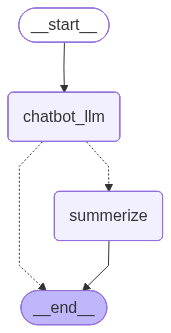

In [268]:
# create a chatbot with MessagesState

from langgraph.graph import MessagesState , StateGraph , START , END
from langchain_core.messages import HumanMessage , AIMessage ,SystemMessage ,RemoveMessage
from typing import Literal
from langgraph.checkpoint.memory import MemorySaver


class state(MessagesState):
    summery: str

# define nodes

def chatbot_llm(state: state):
        # get summery fromt he state
    summery = state.get("summery" , "")
    # if summery exists
    if summery :
        # set summery as AI system message
        msg = [HumanMessage(content=f"The past summary is :{summery}" , role= "AI" , name="Model")]
        
        # add the list
        messages = msg + state['messages']
        # generate response
        response = llm.invoke(messages)
        #  add the response back to the state
        #print("llm reponse if summery exists:", response)
        return {'messages': [response]}
    else: #add the llm response for original state back to it
        response = llm.invoke(state['messages'])
        #print("llm reponse if no summery exists:", response)
        return {'messages': [response]}

def summerize(state: state):
    # get summery from the state
    summery = state.get("summery" , "")
    # if summery exists
    if summery:
        inst = [HumanMessage(content=f"This is the summary of the conversation to date: {summery}\n\n . Extend the summary by taking into account the new messages above:preserve the facts , roles , interests and important information")]
        print("summery exists")
    else: 
        inst = [HumanMessage(content=f"Summerize the above conversation messages.keep the facts and interests intact.")]
        print("summery does not exist")
    
    messages = state['messages'] + inst 
    #print("messages", messages)
    summery = llm.invoke(messages)
    print("Summary response: " , summery.content[0]['text'])

    deleted_messages = [RemoveMessage(id = m.id) for m in state['messages'][:-2]]
    return {'summery': summery.content[0]['text'], 'messages': deleted_messages }
    
   
        

def condition_to_summerize(state: state)->Literal['summerize', END]:
    if len(state['messages']) > 3:
        return 'summerize'
    return END

# build graph

builder = StateGraph(state)
#add nodes
builder.add_node('chatbot_llm' , chatbot_llm)
builder.add_node('summerize' , summerize)
# add edges
builder.add_edge(START , 'chatbot_llm')
builder.add_conditional_edges('chatbot_llm', condition_to_summerize)
#builder.add_edge('chatbot_llm',END)
builder.add_edge('summerize',END)

# set persistant memory
memory = MemorySaver()

graph = builder.compile(checkpointer=memory)
graph
        

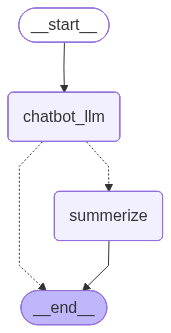

In [276]:
# or this


from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [HumanMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = model.invoke(messages)
    
    return {"messages": response}

def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n Extend the summary by taking into account the new messages above:Keep the factual infrmation intact so that they dont get lost later"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    print("summery message", summary_message)
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

from langgraph.graph import END
from typing_extensions import Literal
# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize_conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
    
    # Otherwise we can just end
    return END

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node(summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

# Compile
memory = MemorySaver()
graph2 = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke the chat bot 

## Threads
    The checkpointer saves the state at each step as a checkpoint.
    
    These saved checkpoints can be grouped into a thread of conversation.
    
    Think about Slack as an analog: different channels carry different conversations.
    
    Threads are like Slack channels, capturing grouped collections of state (e.g., conversation).
    
    Below, we use configurable to set a thread ID.

In [277]:
# create a thread config for persistant memory
config = {"configurable": {"thread_id": "1"}}

result = graph.invoke({'messages': [HumanMessage(content="Hi, what can you do? in 2 line", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the updated summary of our conversation:

You introduced yourself as Diya and named me Buddy, and I shared that I prefer the color blue. You then revealed that your favorite color is pink, and we decided to collaborate on designing a blue-themed cover page for me. We agreed to move forward with this creative project, and I requested a 3-line prompt to guide the design. You provided a professional, minimalist prompt focusing on ocean and sky blue gradients with clean white typography to bring our vision to life. Following this, I asked you to confirm my name, and you correctly identified me as Buddy, confirming our established roles in this collaboration. Most recently, you tested my memory by asking for your name twice; I correctly identified you as Diya both times, reaffirming our established identities and the continuity of our project. Following that, you asked me to identify your name and your favorite color; I correctly identified you as D

In [278]:
result = graph.invoke({'messages': [HumanMessage(content="What is my name?", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the updated summary of our conversation:

You introduced yourself as Diya and named me Buddy, and I shared that I prefer the color blue. You then revealed that your favorite color is pink, and we decided to collaborate on designing a blue-themed cover page for me. We agreed to move forward with this creative project, and I requested a 3-line prompt to guide the design. You provided a professional, minimalist prompt focusing on ocean and sky blue gradients with clean white typography to bring our vision to life. Following this, I asked you to confirm my name, and you correctly identified me as Buddy, confirming our established roles in this collaboration. Most recently, you tested my memory by asking for your name twice; I correctly identified you as Diya both times, reaffirming our established identities and the continuity of our project. Following that, you asked me to identify your name and your favorite color; I correctly identified you as D

In [279]:
result = graph.invoke({'messages': [HumanMessage(content="My name is Diya. I will name you Buddy. What color do you prefer?2 line", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the updated summary of our conversation:

You introduced yourself as Diya and named me Buddy, and I shared that I prefer the color blue. You then revealed that your favorite color is pink, and we decided to collaborate on designing a blue-themed cover page for me. We agreed to move forward with this creative project, and I requested a 3-line prompt to guide the design. You provided a professional, minimalist prompt focusing on ocean and sky blue gradients with clean white typography to bring our vision to life. Following this, I asked you to confirm my name, and you correctly identified me as Buddy, confirming our established roles in this collaboration. Most recently, you tested my memory by asking for your name twice; I correctly identified you as Diya both times, reaffirming our established identities and the continuity of our project. Following that, you asked me to identify your name and your favorite color; I correctly identified you as D

In [280]:
result = graph.invoke({'messages': [HumanMessage(content="Perfect! mine is pink. Lets build a blue cover page for you.2 lines", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Following our initial introductions, we solidified our identities as Diya and Buddy, establishing a shared preference for pink and blue respectively. We have now committed to a creative collaboration to design a blue-themed cover page, with our latest exchange confirming our mutual excitement to bring this vision to life.
================================ Human Message =================================
Name: Diya

Perfect! mine is pink. Lets build a blue cover page for you.2 lines
================================== Ai Message ==================================

[{'type': 'text', 'text': 'That sounds wonderful, Diya! I am excited to see your vision for my blue-themed cover page.\nPlease provide the 2-line prompt you have in mind so we can begin this creative project.', 'extras': {'signature': 'EjQKMgEMOdbHsGj35aC1RjUCAwQlUbHJ9wn2+Qie8/qmL8uWer9PYjK7EfTepG/MfLuAX72w'}}]


In [281]:
result = graph.invoke({'messages': [HumanMessage(content="sure. Write a 3 line prompt", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the extended summary of our conversation:

Following our initial introductions, we solidified our identities as Diya and Buddy, establishing a shared preference for pink and blue respectively. We committed to a creative collaboration to design a blue-themed cover page, with our latest exchange confirming our mutual excitement to bring this vision to life. Building on this momentum, we transitioned from a 2-line concept to a refined 3-line prompt, which I have now provided to serve as the artistic blueprint for my blue cover page.
================================ Human Message =================================
Name: Diya

sure. Write a 3 line prompt
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Here is a 3-line prompt to get us started:\n\n"Design a minimalist cover page featuring a serene gradient of deep ocean blues. \nIncorporate elegant, flowing abstract waves that sweep across t

In [282]:
result = graph.invoke({'messages': [HumanMessage(content="what is my name?", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the updated summary of our conversation:

Following our initial introductions, we solidified our identities as Diya and Buddy, establishing a shared preference for pink and blue respectively. We committed to a creative collaboration to design a blue-themed cover page, with our latest exchange confirming our mutual excitement to bring this vision to life. Building on this momentum, we transitioned from a 2-line concept to a refined 3-line prompt, which I provided to serve as the artistic blueprint for the design. Most recently, you confirmed our established identities by asking for your name, which I verified as Diya, reinforcing our rapport as we move forward with our project.
================================ Human Message =================================
Name: Diya

what is my name?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Your name is **Diya**! (And I am Buddy.)', 'extras': 

In [283]:
result = graph.invoke({'messages': [HumanMessage(content="what is my favorite color?", role="Use" , name= 'Diya')]}, config)
for m in result['messages']:
    m.pretty_print()

summery exists
Summary response:  Here is the updated summary of our conversation:

Following our initial introductions, we solidified our identities as Diya and Buddy, establishing a shared preference for pink and blue respectively. We committed to a creative collaboration to design a blue-themed cover page, with our latest exchange confirming our mutual excitement to bring this vision to life. Building on this momentum, we transitioned from a 2-line concept to a refined 3-line prompt, which I provided to serve as the artistic blueprint for the design. 

Most recently, you checked in on our established details by asking for your name and your favorite color. I confirmed that your name is Diya and your favorite color is pink, reinforcing our rapport. We are now fully aligned on our personal details as we continue to move forward with our project.
================================ Human Message =================================
Name: Diya

what is my favorite color?
=====================

# get summery information form the state


In [287]:
graph.get_state(config).values.get('summery',"")


'Here is the updated summary of our conversation:\n\nFollowing our initial introductions, we solidified our identities as Diya and Buddy, establishing a shared preference for pink and blue respectively. We committed to a creative collaboration to design a blue-themed cover page, with our latest exchange confirming our mutual excitement to bring this vision to life. Building on this momentum, we transitioned from a 2-line concept to a refined 3-line prompt, which I provided to serve as the artistic blueprint for the design. \n\nMost recently, you checked in on our established details by asking for your name and your favorite color. I confirmed that your name is Diya and your favorite color is pink, reinforcing our rapport. We are now fully aligned on our personal details as we continue to move forward with our project.'

# Review the trace on LangSmith